# IntZ Example 8: Size-Mass Relation
**EPS Research IntZ Kinematic Corpus v1.0**

Plot half-light radius vs stellar mass for Tier-1 KROSS galaxies.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

# Load IntZ corpus
with open('/home/david/Documents/RAG Project/Z=2 RAG/Zenodo/intz_corpus_v1b.json') as f:
    data = json.load(f)
galaxies = data['galaxies']
print(f"Loaded {len(galaxies)} galaxies")

Loaded 1292 galaxies


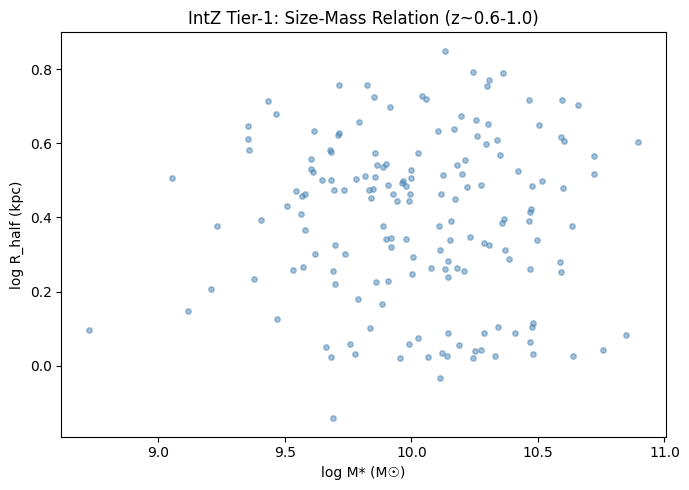

In [2]:
t1 = [g for g in galaxies if g['metadata']['quality_tier']==1]
lm, rh = [], []
for g in t1:
    sp = g.get('stellar_properties', {})
    m = sp.get('log_mass_msun')
    r = g.get('morphology', {}).get('R_half_kpc')
    if m and r and r > 0:
        lm.append(m); rh.append(np.log10(r))

fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(lm, rh, c='steelblue', alpha=0.5, s=15)
ax.set_xlabel('log M* (M☉)')
ax.set_ylabel('log R_half (kpc)')
ax.set_title('IntZ Tier-1: Size-Mass Relation (z~0.6-1.0)')
plt.tight_layout()
plt.savefig('intz_nb8_size_mass.png', dpi=120)
plt.show()